In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_text

# Load data
youth_df = pd.read_csv("youth_data.csv")

# Predictor variables
predictor_vars = [
    'PARCHKHW', 'PARHLPHW', 'PRCHORE2', 'PRLMTTV2', 'PARLMTSN', 'PRGDJOB2',
    'PRPROUD2', 'PRPKCIG2', 'PRMJEVR2', 'PRMJMO', 'PRALDLY2',
    'FRDPCIG2', 'FRDMEVR2', 'FRDMJMON', 'FRDADLY2',
    'SCHFELT', 'TCHGJOB', 'AVGGRADE', 'STNDSCIG', 'STNDSMJ', 'STNDALC', 'STNDDNK'
]

column_rename_map = {
    'PARCHKHW': 'Parents check if homework is done (past year)',
    'PARHLPHW': 'Parents help with homework (past year)',
    'PRCHORE2': 'Parents make youth do chores (past year)',
    'PRLMTTV2': 'Parents limit amount of TV (past year)',
    'PARLMTSN': 'Parents limit time out on school night (past year)',
    'PRGDJOB2': 'Parents say youth did a good job (past year)',
    'PRPROUD2': 'Parents express pride in youth (past year)',
    'PRPKCIG2': 'Parents discourage youth from smoking cigarettes',
    'PRMJEVR2': 'Parents discourage youth from trying marijuana',
    'PRMJMO': 'Parents discourage youth from monthly marijuana use',
    'PRALDLY2': 'Parents discourage youth from daily alcohol use',
    'FRDPCIG2': 'Friends would disapprove if youth smoked cigarettes',
    'FRDMEVR2': 'Friends would disapprove if youth tried marijuana',
    'FRDMJMON': 'Friends would disapprove if youth used marijuana monthly',
    'FRDADLY2': 'Friends would disapprove if youth drank alcohol daily',
    'SCHFELT': 'Youth feels part of school',
    'TCHGJOB': 'Teachers say youth is doing a good job',
    'AVGGRADE': 'Youth’s average school grade',
    'STNDSCIG': 'Perceived student cigarette use (most/all vs few/none)',
    'STNDSMJ': 'Perceived student marijuana use (most/all vs few/none)',
    'STNDALC': 'Perceived student alcohol use (most/all vs few/none)',
    'STNDDNK': 'Perceived student drunkenness frequency (weekly)',
}


# Binary Classification: ALCFLAG

In [43]:


# Clean and prepare data
alc_df = youth_df[predictor_vars + ['ALCFLAG']].copy()
alc_df = alc_df.replace([91, 93, 94, 95, 97, 98, 99, 991, 993, 994, 997, 998, 999], np.nan)
alc_df.dropna(inplace=True)

X = alc_df[predictor_vars]
y = alc_df['ALCFLAG']
X_train_full, X_test_full, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Fit a temporary tree to get top 10 features
temp_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
temp_tree.fit(X_train_full, y_train)
feature_importances = pd.Series(temp_tree.feature_importances_, index=X.columns)
top_10_features = feature_importances.sort_values(ascending=False).head(10).index.tolist()

# Remove 'STNDALC' if it's in the list
if 'STNDALC' in top_10_features:
    top_10_features.remove('STNDALC')

print("Top features after removal:", top_10_features)



Top features after removal: ['FRDMJMON', 'FRDPCIG2', 'PRMJEVR2', 'STNDSMJ', 'PRMJMO', 'PARCHKHW', 'FRDMEVR2', 'PRLMTTV2', 'PRGDJOB2']


In [44]:

# Step 2: Use only top 10 features for the final tree
X_train = X_train_full[top_10_features]
X_test = X_test_full[top_10_features]

# Step 3: Tune depth
scores = []
depths = list(range(1, 21))
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    scores.append(accuracy_score(y_test, preds))

best_depth = depths[scores.index(max(scores))]


In [45]:
from sklearn.metrics import mean_squared_error

train_mse_scores = []
test_mse_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_preds)
    test_mse = mean_squared_error(y_test, test_preds)
    
    train_mse_scores.append(train_mse)
    test_mse_scores.append(test_mse)


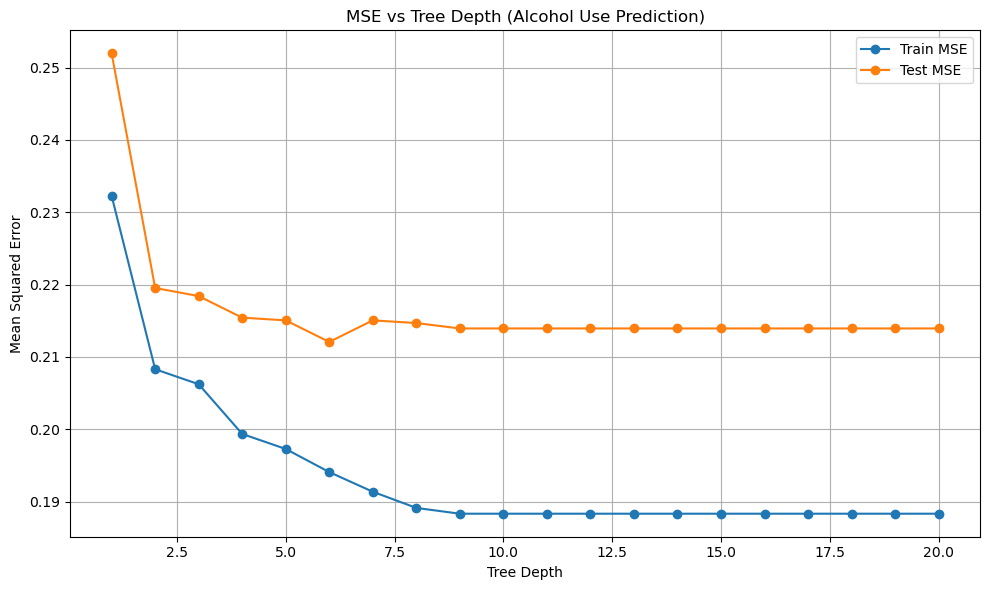

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(depths, train_mse_scores, marker='o', label='Train MSE')
plt.plot(depths, test_mse_scores, marker='o', label='Test MSE')
plt.title("MSE vs Tree Depth (Alcohol Use Prediction)")
plt.xlabel("Tree Depth")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


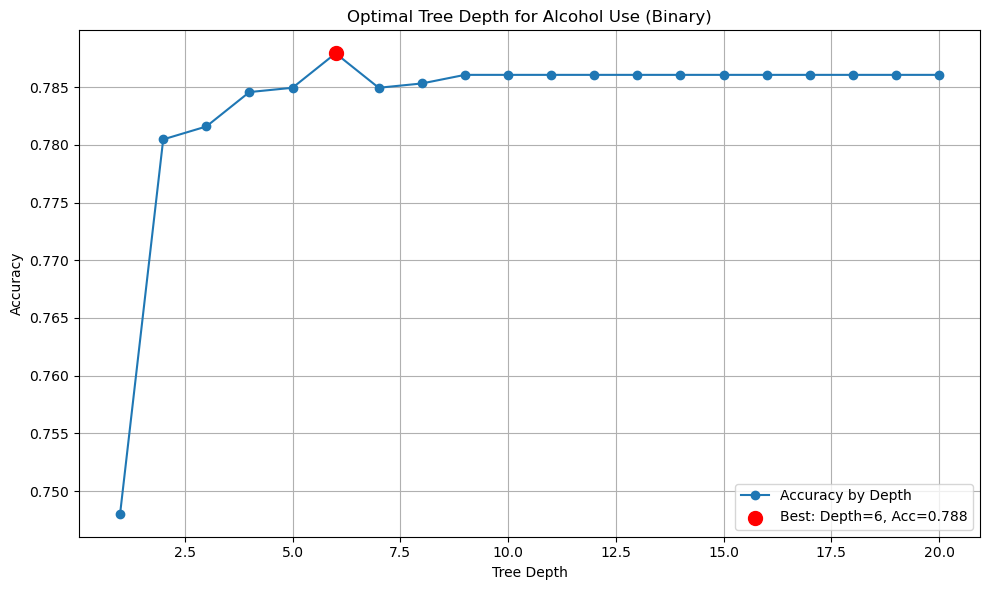

In [54]:

# Train best model using top 10 features
best_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
best_model.fit(X_train, y_train)

# Plot depth vs. accuracy
plt.figure(figsize=(10, 6))
plt.plot(depths, scores, marker='o', label='Accuracy by Depth')
plt.scatter(best_depth, max(scores), color='red', s=100, zorder=5, label=f'Best: Depth={best_depth}, Acc={max(scores):.3f}')
plt.title("Optimal Tree Depth for Alcohol Use (Binary)")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
dt_test_preds = best_model.predict(X_train)

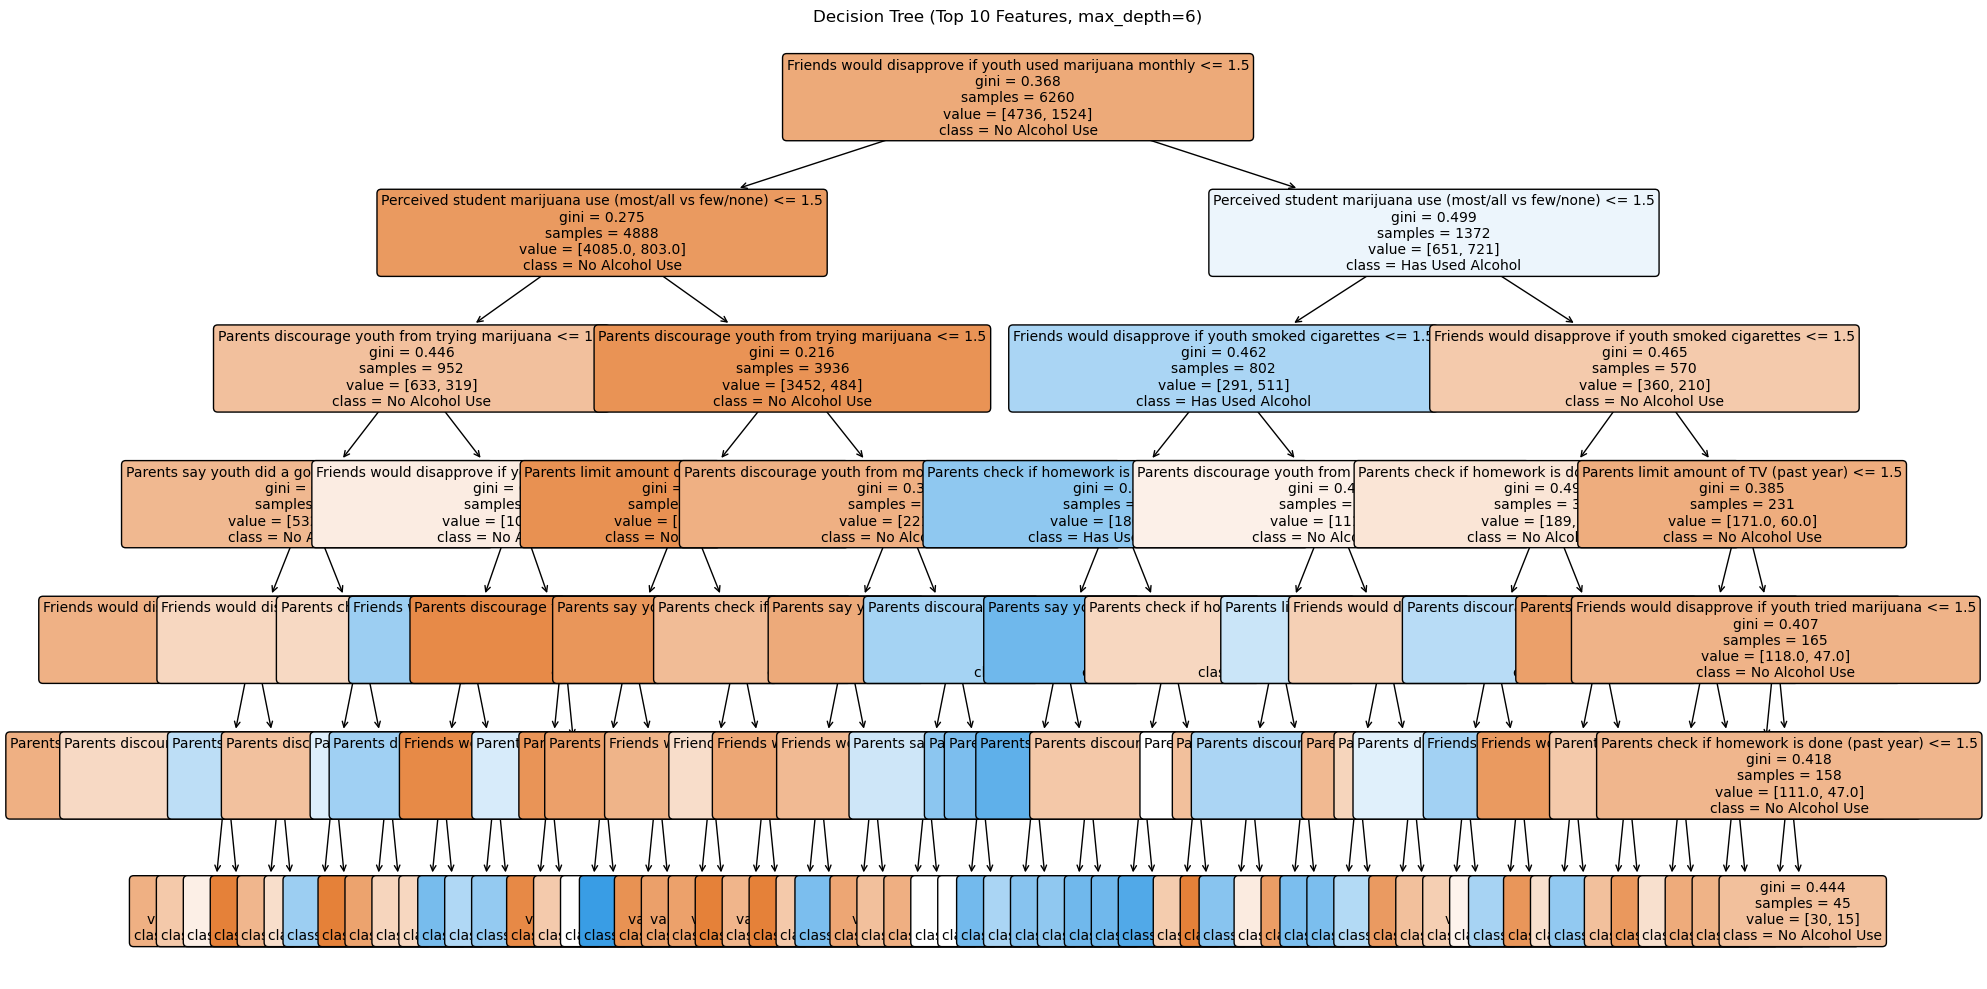

In [48]:
# Ensure you're renaming only relevant feature names
relabeled_features = [column_rename_map.get(col, col) for col in top_10_features]

plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=relabeled_features,
    class_names=["No Alcohol Use", "Has Used Alcohol"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree (Top 10 Features, max_depth={best_depth})")
plt.tight_layout()
plt.show()


In [49]:

# Print text version
tree_summary = export_text(best_model, feature_names=relabeled_features)
print(tree_summary)

|--- Friends would disapprove if youth used marijuana monthly <= 1.50
|   |--- Perceived student marijuana use (most/all vs few/none) <= 1.50
|   |   |--- Parents discourage youth from trying marijuana <= 1.50
|   |   |   |--- Parents say youth did a good job (past year) <= 1.50
|   |   |   |   |--- Friends would disapprove if youth smoked cigarettes <= 1.50
|   |   |   |   |   |--- Parents discourage youth from monthly marijuana use <= 1.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Parents discourage youth from monthly marijuana use >  1.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Friends would disapprove if youth smoked cigarettes >  1.50
|   |   |   |   |   |--- Parents discourage youth from monthly marijuana use <= 1.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Parents discourage youth from monthly marijuana use >  1.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- Parents say youth did a good job (past year) >  1

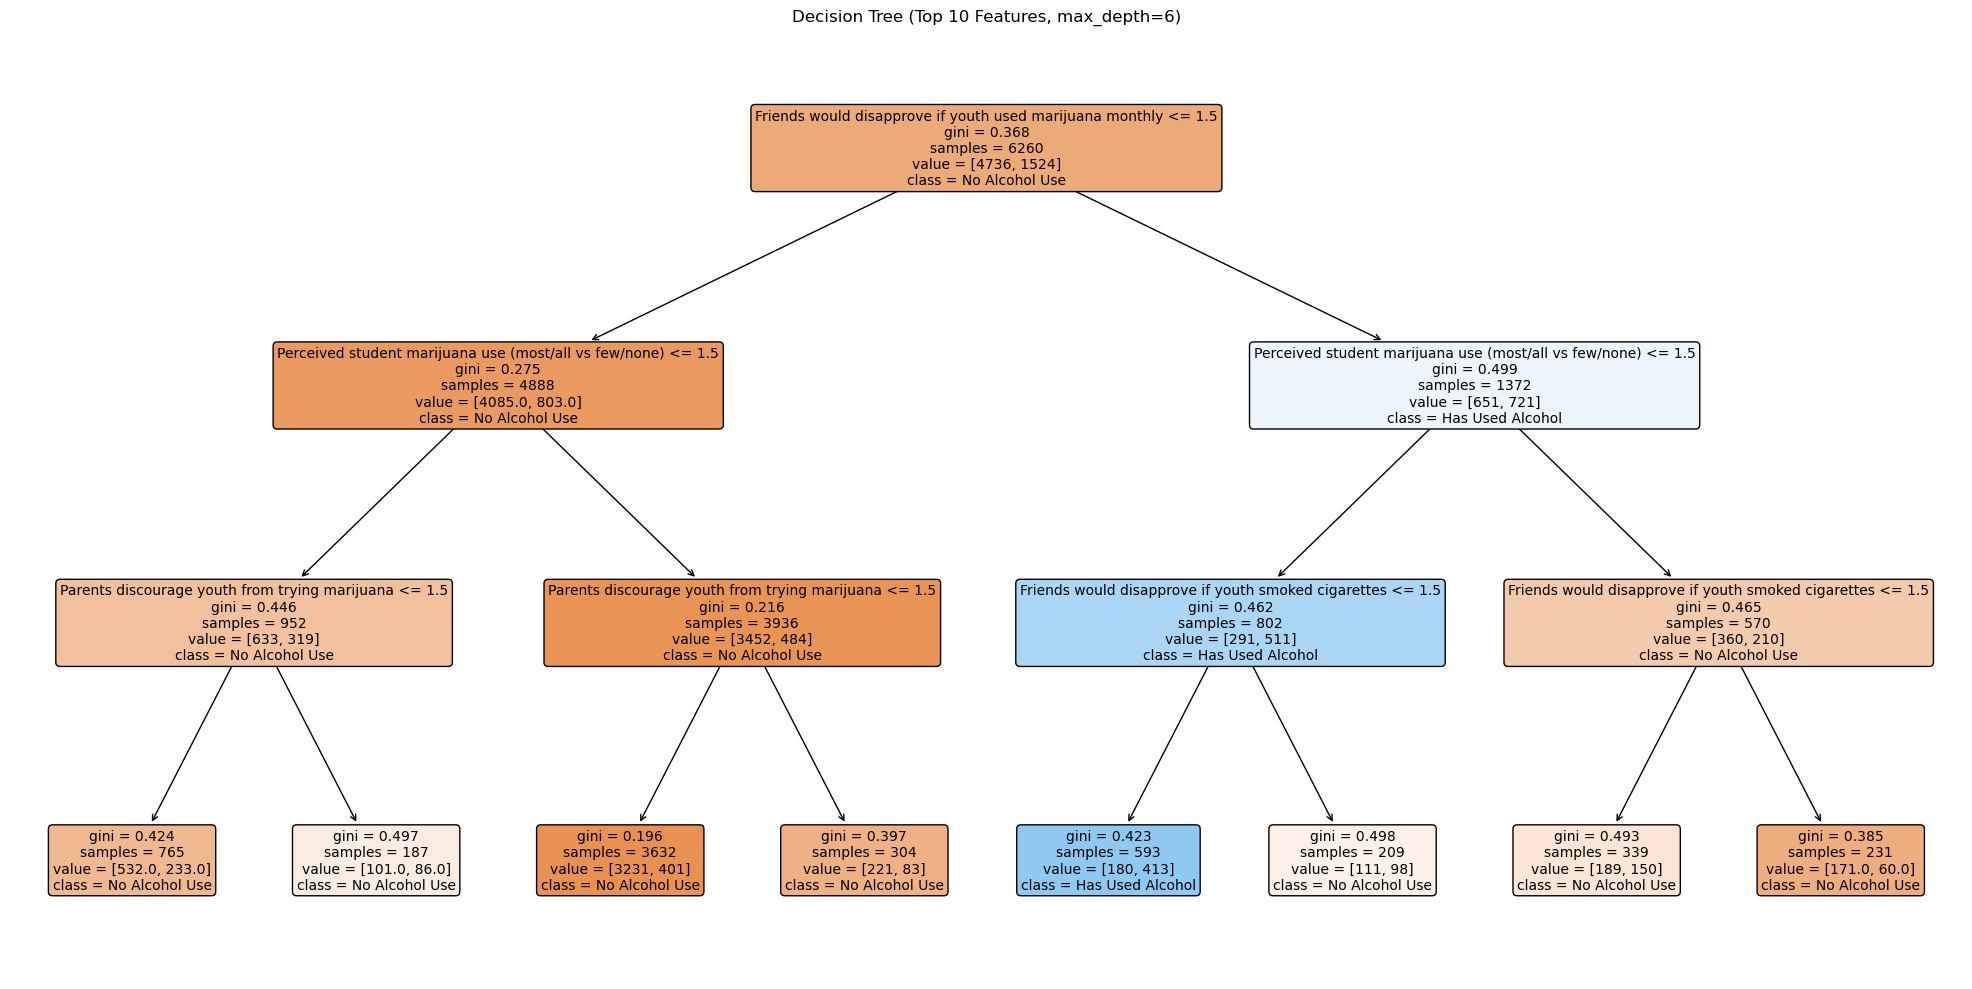

In [50]:
best_model = DecisionTreeClassifier(max_depth=3, random_state=42)
best_model.fit(X_train, y_train)
#  Visualize decision tree
relabeled_features = [column_rename_map.get(col, col) for col in top_10_features]
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=relabeled_features,
    class_names=["No Alcohol Use", "Has Used Alcohol"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Decision Tree (Top 10 Features, max_depth={best_depth})")
plt.tight_layout()
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

# Prepare data
X_train_rf = X_train_full[top_10_features]
X_test_rf = X_test_full[top_10_features]

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,  # Let trees grow fully
    random_state=42
)
rf_model.fit(X_train_rf, y_train)

# Predict
rf_preds = rf_model.predict(X_test_rf)
rf_train_preds = rf_model.predict(X_train_rf)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_train_accuracy = accuracy_score(y_train, rf_train_preds)
rf_test_mse = mean_squared_error(y_test, rf_preds)
rf_train_mse = mean_squared_error(y_train, rf_train_preds)

print(f"🎯 Random Forest Accuracy (Train): {rf_train_accuracy:.4f}")
print(f"🎯 Random Forest Accuracy (Test):  {rf_accuracy:.4f}")
print(f"📉 Random Forest MSE (Train):     {rf_train_mse:.4f}")
print(f"📉 Random Forest MSE (Test):      {rf_test_mse:.4f}")


🎯 Random Forest Accuracy (Train): 0.8117
🎯 Random Forest Accuracy (Test):  0.7842
📉 Random Forest MSE (Train):     0.1883
📉 Random Forest MSE (Test):      0.2158


In [52]:
print("----- Model Comparison -----")
print(f"Decision Tree Accuracy (Test): {max(scores):.4f}")
print(f"Random Forest Accuracy (Test): {rf_accuracy:.4f}")

----- Model Comparison -----
Decision Tree Accuracy (Test): 0.7879
Random Forest Accuracy (Test): 0.7842


In [55]:
print("----- Model Comparison -----")
print(f"Decision Tree Accuracy (Train): {accuracy_score(y_train, dt_test_preds)}")
print(f"Random Forest Accuracy (Test): {rf_train_accuracy:.4f}")

----- Model Comparison -----
Decision Tree Accuracy (Train): 0.8059105431309904
Random Forest Accuracy (Test): 0.8117


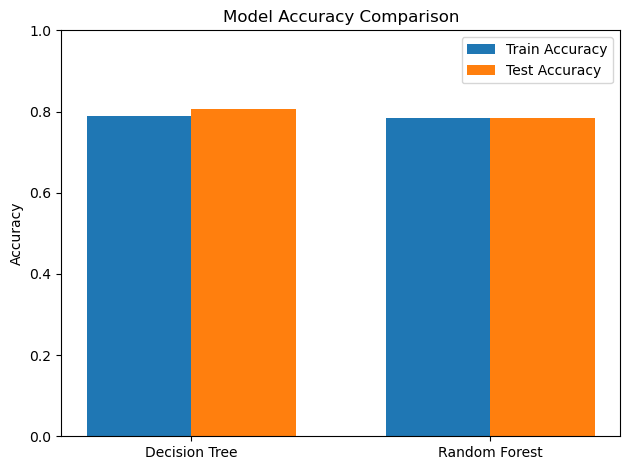

In [56]:
dt_train_accuracy = max(scores)
rf_train_accuracy = rf_accuracy
dt_test_accuracy = accuracy_score(y_train, dt_test_preds)
rf_test_accuracy = rf_train_accuracy
# Plotting
models = ['Decision Tree', 'Random Forest']
train_accuracies = [dt_train_accuracy, rf_train_accuracy]
test_accuracies = [dt_test_accuracy, rf_test_accuracy]

x = range(len(models))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x, train_accuracies, width, label='Train Accuracy')
ax.bar([i + width for i in x], test_accuracies, width, label='Test Accuracy')

# Formatting
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks([i + width / 2 for i in x])
ax.set_xticklabels(models)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("Criterion used:", best_model.criterion)
gini_values = best_model.tree_.impurity
samples_per_node = best_model.tree_.n_node_samples
for i in range(len(gini_values)):
    print(f"Node {i}: Gini = {gini_values[i]:.4f}, Samples = {samples_per_node[i]}")



Criterion used: gini
Node 0: Gini = 0.3684, Samples = 6260
Node 1: Gini = 0.2746, Samples = 4888
Node 2: Gini = 0.4456, Samples = 952
Node 3: Gini = 0.4236, Samples = 765
Node 4: Gini = 0.4002, Samples = 600
Node 5: Gini = 0.3967, Samples = 583
Node 6: Gini = 0.3951, Samples = 572
Node 7: Gini = 0.4628, Samples = 11
Node 8: Gini = 0.4844, Samples = 17
Node 9: Gini = 0.4978, Samples = 15
Node 10: Gini = 0.0000, Samples = 2
Node 11: Gini = 0.4824, Samples = 165
Node 12: Gini = 0.4773, Samples = 155
Node 13: Gini = 0.4178, Samples = 37
Node 14: Gini = 0.4884, Samples = 118
Node 15: Gini = 0.4800, Samples = 10
Node 16: Gini = 0.4444, Samples = 9
Node 17: Gini = 0.0000, Samples = 1
Node 18: Gini = 0.4968, Samples = 187
Node 19: Gini = 0.4840, Samples = 151
Node 20: Gini = 0.4467, Samples = 98
Node 21: Gini = 0.3343, Samples = 33
Node 22: Gini = 0.4800, Samples = 65
Node 23: Gini = 0.4956, Samples = 53
Node 24: Gini = 0.4824, Samples = 32
Node 25: Gini = 0.3628, Samples = 21
Node 26: Gini = 

# Multi-class Classification: IRCIGFM

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Clean data
multi_df = youth_df[predictor_vars + ['IRCIGFM']].copy()
multi_df.replace([91, 93, 94, 95, 97, 98, 99, 991, 993, 994, 997, 998, 999], np.nan, inplace=True)
multi_df.dropna(inplace=True)

# Keep only valid target classes
valid_classes = multi_df['IRCIGFM'].value_counts()
multi_df = multi_df[multi_df['IRCIGFM'].isin(valid_classes[valid_classes >= 2].index)]

# Define features and target
X = multi_df[predictor_vars]
y = multi_df['IRCIGFM']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# Select top 15 features
selector = SelectKBest(score_func=f_classif, k=10)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)
selected_features = X.columns[selector.get_support()]

print("Top selected features:", list(selected_features))


# Model definitions
models_params = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [3, 5, 6, 7, 10]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, 20, 25]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [20,25, 50, 100], 'max_depth': [1,2,3, 5, 10, 15], 'learning_rate': [0.1, 1.0, 0.01]}
    ),
}

# Storage for results
best_models = {}
results = {}

for name, (model, params) in models_params.items():
    print(f"\n🔍 Tuning {name}...")
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Best Params for {name}: {grid.best_params_}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))


Top selected features: ['PRCHORE2', 'PRGDJOB2', 'PRPROUD2', 'PRPKCIG2', 'PRALDLY2', 'TCHGJOB', 'AVGGRADE', 'STNDSMJ', 'STNDALC', 'STNDDNK']

🔍 Tuning Decision Tree...
✅ Best Params for Decision Tree: {'max_depth': 3}
🎯 Accuracy: 0.3158
📋 Classification Report:
               precision    recall  f1-score   support

         1.0       0.40      0.92      0.56        13
         2.0       0.00      0.00      0.00         8
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         2
         5.0       0.00      0.00      0.00         3
         6.0       0.00      0.00      0.00         1
         7.0       0.00      0.00      0.00         0
        10.0       0.00      0.00      0.00         2
        15.0       0.00      0.00      0.00         1
        20.0       0.00      0.00      0.00         1
        23.0       0.00      0.00      0.00         1
        25.0       0.00      0.00      0.00         1
        30.0       0.00      0.00  

d:\Software\Anaconda\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples.

✅ Best Params for Random Forest: {'max_depth': 5, 'n_estimators': 100}
🎯 Accuracy: 0.3421
📋 Classification Report:
               precision    recall  f1-score   support

         1.0       0.37      0.85      0.51        13
         2.0       0.33      0.25      0.29         8
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         2
         5.0       0.00      0.00      0.00         3
         6.0       0.00      0.00      0.00         1
         8.0       0.00      0.00      0.00         0
        10.0       0.00      0.00      0.00         2
        15.0       0.00      0.00      0.00         1
        20.0       0.00      0.00      0.00         1
        23.0       0.00      0.00      0.00         1
        25.0       0.00      0.00      0.00         1
        30.0       0.00      0.00      0.00         1

    accuracy                           0.34        38
   macro avg       0.05      0.08      0.06        38
weighted avg      

d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_clas

✅ Best Params for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 20}
🎯 Accuracy: 0.3421
📋 Classification Report:
               precision    recall  f1-score   support

         1.0       0.34      1.00      0.51        13
         2.0       0.00      0.00      0.00         8
         3.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         2
         5.0       0.00      0.00      0.00         3
         6.0       0.00      0.00      0.00         1
        10.0       0.00      0.00      0.00         2
        15.0       0.00      0.00      0.00         1
        20.0       0.00      0.00      0.00         1
        23.0       0.00      0.00      0.00         1
        25.0       0.00      0.00      0.00         1
        30.0       0.00      0.00      0.00         1

    accuracy                           0.34        38
   macro avg       0.03      0.08      0.04        38
weighted avg       0.12      0.34      0.17   

d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


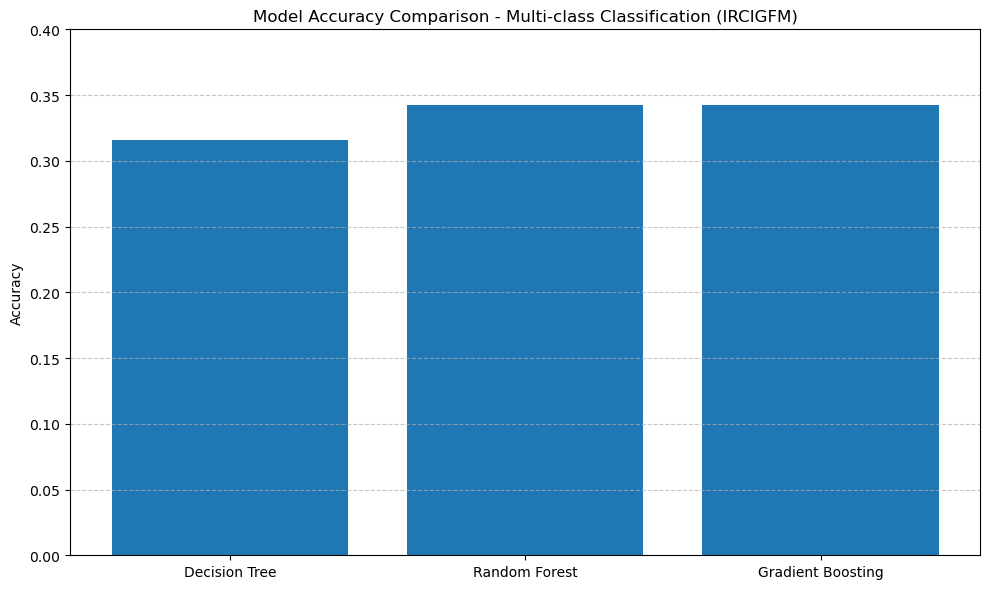

In [62]:
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison - Multi-class Classification (IRCIGFM)")
plt.ylim(0, 0.4)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Regression: CIGMDAYS

In [ ]:
reg_df = youth_df[predictor_vars + ['CIGMDAYS']].copy()
reg_df = reg_df.replace([91, 93, 94, 95, 97, 98, 99, 991, 993, 994, 997, 998, 999], np.nan)
reg_df.dropna(inplace=True)

X_reg = reg_df[predictor_vars]
y_reg = reg_df['CIGMDAYS']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
from sklearn.model_selection import GridSearchCV

# Decision Tree
dtr_params = {'max_depth': [3, 5, 7, 10]}
dtr_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dtr_params, cv=5)
dtr_grid.fit(X_train_r, y_train_r)

# Random Forest
rfr_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, 15]}
rfr_grid = GridSearchCV(RandomForestRegressor(random_state=42), rfr_params, cv=5)
rfr_grid.fit(X_train_r, y_train_r)

# Gradient Boosting
gbr_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1]}
gbr_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gbr_params, cv=5)
gbr_grid.fit(X_train_r, y_train_r)


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]})

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Evaluate all three models
models = {
    'Decision Tree': dtr_grid,
    'Random Forest': rfr_grid,
    'Gradient Boosting': gbr_grid
}

print("📊 Regression Model Evaluation:")
for name, model in models.items():
    preds = model.predict(X_test_r)
    r2 = r2_score(y_test_r, preds)
    mae = mean_absolute_error(y_test_r, preds)
    rmse = np.sqrt(mean_squared_error(y_test_r, preds))
    print(f"\n{name}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")


📊 Regression Model Evaluation:

Decision Tree
✅ R² Score: 0.0057
📉 MAE: 0.1116
📉 RMSE: 0.5079

Random Forest
✅ R² Score: 0.0138
📉 MAE: 0.1110
📉 RMSE: 0.5058

Gradient Boosting
✅ R² Score: 0.0200
📉 MAE: 0.1141
📉 RMSE: 0.5042


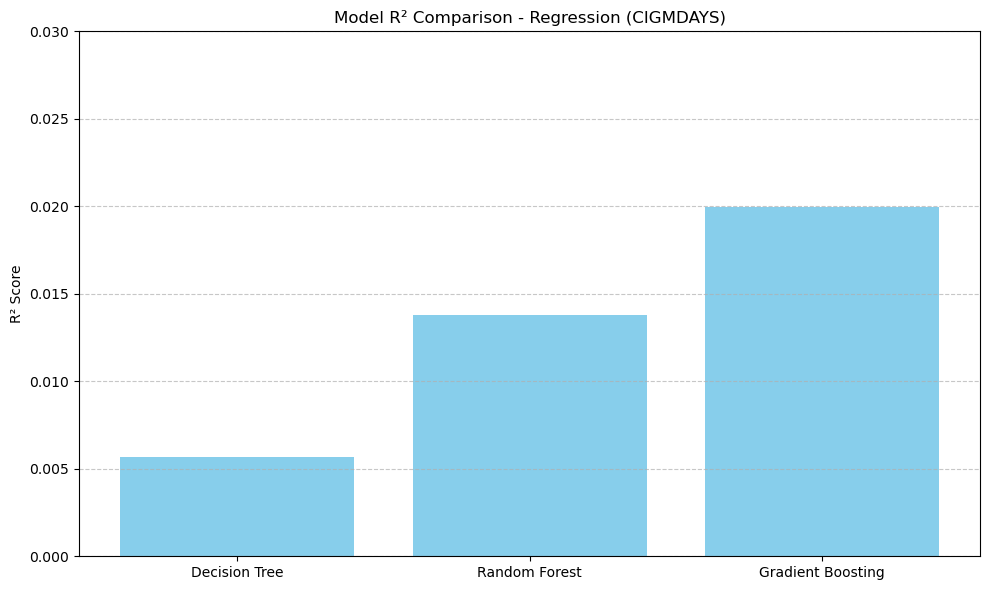

In [ ]:
from sklearn.metrics import r2_score

# Dummy placeholder predictions; replace with actual model objects if running in notebook
# For now, we use hypothetical R² scores
r2_scores = {
    "Decision Tree": r2_score(y_test_r, dtr_grid.predict(X_test_r)),
    "Random Forest": r2_score(y_test_r, rfr_grid.predict(X_test_r)),
    "Gradient Boosting": r2_score(y_test_r, gbr_grid.predict(X_test_r))
}
# Plotting the R² comparison
plt.figure(figsize=(10, 6))
plt.bar(r2_scores.keys(), r2_scores.values(), color='skyblue')
plt.ylabel("R² Score")
plt.title("Model R² Comparison - Regression (CIGMDAYS)")
plt.ylim(0, 0.03) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()